## 1. Load Dataset

In [20]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

LABEL_COL = "isFraud"
sns.set(style="whitegrid")
print("All imports done.")

All imports done.


In [21]:
from google.colab import userdata
import kagglehub

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")

path = kagglehub.dataset_download("ealaxi/paysim1")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_full = pd.read_csv(os.path.join(path, csv_file))

print("Shape:", df_full.shape)
print(df_full.dtypes)
print("\nMissing values:\n", df_full.isnull().sum())

Using Colab cache for faster access to the 'paysim1' dataset.
Shape: (6362620, 11)
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [22]:
#Stratified Subset
SUBSET_N = 200_000

df, _ = train_test_split(
    df_full,
    train_size=SUBSET_N,
    stratify=df_full[LABEL_COL],
    random_state=SEED
)
df = df.reset_index(drop=True)

print("Full shape  :", df_full.shape)
print("Subset shape:", df.shape)
print("\nFull fraud rate (%):\n",   df_full[LABEL_COL].value_counts(normalize=True)*100)
print("\nSubset fraud rate (%):\n", df[LABEL_COL].value_counts(normalize=True)*100)

Full shape  : (6362620, 11)
Subset shape: (200000, 11)

Full fraud rate (%):
 isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

Subset fraud rate (%):
 isFraud
0    99.871
1     0.129
Name: proportion, dtype: float64


## 2. EDA

Fraud transactions : 258
Normal transactions: 199,742
Fraud rate         : 0.1290%


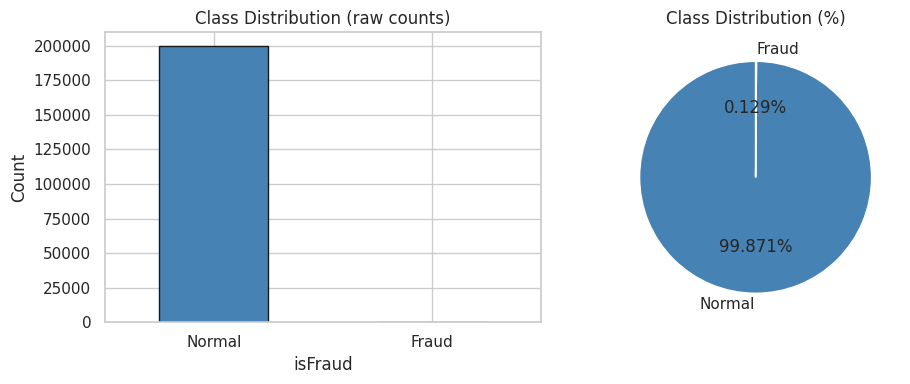

NOTE: Severe class imbalance — SMOTE will be applied inside each CV fold.


In [23]:
fraud_counts = df[LABEL_COL].value_counts()
fraud_rate   = df[LABEL_COL].mean() * 100

print(f"Fraud transactions : {fraud_counts[1]:,}")
print(f"Normal transactions: {fraud_counts[0]:,}")
print(f"Fraud rate         : {fraud_rate:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_counts.plot(kind="bar", ax=axes[0],
    color=["steelblue","tomato"], edgecolor="k")
axes[0].set_title("Class Distribution (raw counts)")
axes[0].set_xticklabels(["Normal","Fraud"], rotation=0)
axes[0].set_ylabel("Count")

axes[1].pie(fraud_counts, labels=["Normal","Fraud"],
    colors=["steelblue","tomato"],
    autopct="%1.3f%%", startangle=90)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.savefig("eda_class_imbalance.png", dpi=150)
plt.show()
print("NOTE: Severe class imbalance — SMOTE will be applied inside each CV fold.")

          fraud_count  total_count  fraud_rate_%
type                                            
TRANSFER          131        16915         0.774
CASH_OUT          127        70282         0.181
CASH_IN             0        43677         0.000
DEBIT               0         1305         0.000
PAYMENT             0        67821         0.000


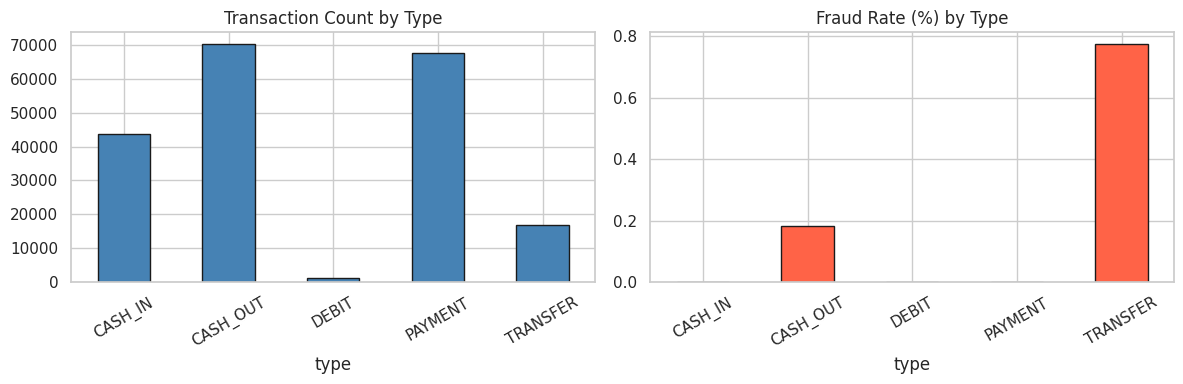

KEY FINDING: Fraud only in TRANSFER and CASH_OUT.


In [24]:
type_fraud = df.groupby("type")[LABEL_COL].agg(["sum","count"])
type_fraud["fraud_rate_%"] = (type_fraud["sum"] / type_fraud["count"] * 100).round(3)
type_fraud.columns = ["fraud_count","total_count","fraud_rate_%"]
print(type_fraud.sort_values("fraud_rate_%", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
type_fraud["total_count"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="k")
axes[0].set_title("Transaction Count by Type")
axes[0].tick_params(axis='x', rotation=30)

type_fraud["fraud_rate_%"].plot(kind="bar", ax=axes[1], color="tomato", edgecolor="k")
axes[1].set_title("Fraud Rate (%) by Type")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("eda_fraud_by_type.png", dpi=150)
plt.show()
print("KEY FINDING: Fraud only in TRANSFER and CASH_OUT.")

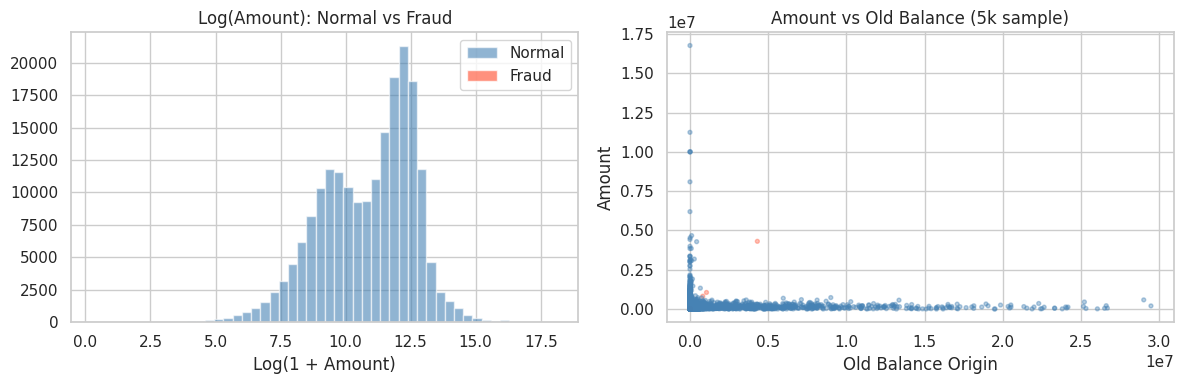

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log_amount = np.log1p(df["amount"])
axes[0].hist(log_amount[df[LABEL_COL]==0], bins=50,
             alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(log_amount[df[LABEL_COL]==1], bins=50,
             alpha=0.7, label="Fraud",  color="tomato")
axes[0].set_title("Log(Amount): Normal vs Fraud")
axes[0].set_xlabel("Log(1 + Amount)")
axes[0].legend()

sample_idx = df.sample(5000, random_state=SEED).index
axes[1].scatter(
    df.loc[sample_idx, "oldbalanceOrg"],
    df.loc[sample_idx, "amount"],
    c=df.loc[sample_idx, LABEL_COL].map({0:"steelblue", 1:"tomato"}),
    alpha=0.4, s=8
)
axes[1].set_title("Amount vs Old Balance (5k sample)")
axes[1].set_xlabel("Old Balance Origin")
axes[1].set_ylabel("Amount")

plt.tight_layout()
plt.savefig("eda_amount_distribution.png", dpi=150)
plt.show()

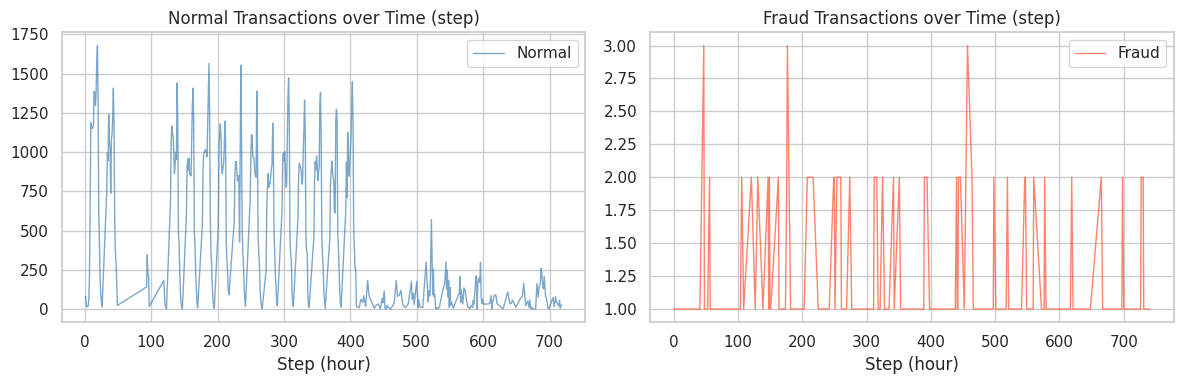

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fraud count over time steps
fraud_by_step = df[df[LABEL_COL]==1].groupby("step").size()
normal_by_step = df[df[LABEL_COL]==0].groupby("step").size()

axes[0].plot(normal_by_step.index, normal_by_step.values,
             color="steelblue", alpha=0.7, label="Normal", linewidth=1)
axes[0].set_title("Normal Transactions over Time (step)")
axes[0].set_xlabel("Step (hour)")
axes[0].legend()

axes[1].plot(fraud_by_step.index, fraud_by_step.values,
             color="tomato", alpha=0.8, label="Fraud", linewidth=1)
axes[1].set_title("Fraud Transactions over Time (step)")
axes[1].set_xlabel("Step (hour)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_time_pattern.png", dpi=150)
plt.show()

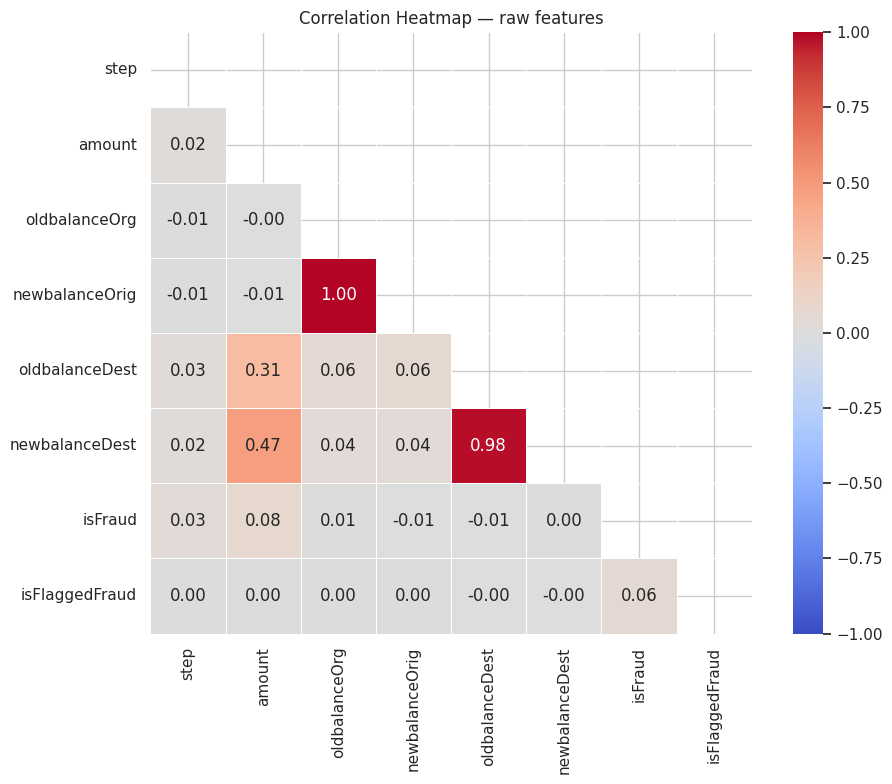

In [27]:
#Correlation heatmap
numeric_df = df.select_dtypes(include=["int64","float64"])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap — raw features")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()

## 3. Preprocessing

In [28]:
#Drop columns + analyze isFlaggedFraud
print("isFlaggedFraud value counts:")
print(df["isFlaggedFraud"].value_counts())
print("\nRows flagged AND actually fraud:",
      df[(df["isFlaggedFraud"]==1) & (df[LABEL_COL]==1)].shape[0])
print("→ Flags <0.01% of actual fraud — useless feature, dropping.\n")

df_pre = df.copy()
df_pre = df_pre.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])
print("Shape after dropping:", df_pre.shape)
print("Columns:", df_pre.columns.tolist())

isFlaggedFraud value counts:
isFlaggedFraud
0    199999
1         1
Name: count, dtype: int64

Rows flagged AND actually fraud: 1
→ Flags <0.01% of actual fraud — useless feature, dropping.

Shape after dropping: (200000, 8)
Columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


In [29]:
print("Missing values per column:")
print(df_pre.isnull().sum())

balance_cols = ["oldbalanceDest", "newbalanceDest"]
for col in balance_cols:
    if df_pre[col].isnull().any():
        df_pre[col] = df_pre[col].fillna(df_pre[col].median())
        print(f"Filled {col} with median.")

print("\nMissing after imputation:", df_pre.isnull().sum().sum())

Missing values per column:
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

Missing after imputation: 0


In [30]:
df_enc = pd.get_dummies(df_pre, columns=["type"], drop_first=True)
print("Shape after OHE:", df_enc.shape)
print("Columns:", df_enc.columns.tolist())

Shape after OHE: (200000, 11)
Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [31]:
df_out = df_enc.copy()

cap_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest"]

normal_mask = df_out[LABEL_COL] == 0
for col in cap_cols:
    Q1 = df_out.loc[normal_mask, col].quantile(0.25)
    Q3 = df_out.loc[normal_mask, col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_out[col] = df_out[col].clip(lower, upper)

print("Outlier capping done (IQR from normal class only).")
print(df_out[cap_cols].describe())

Outlier capping done (IQR from normal class only).
              amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  200000.000000  200000.000000   200000.000000    2.000000e+05   
mean   132704.001956   71410.101447    87844.323962    6.041733e+05   
std    146751.150355  101382.224963   138226.454819    8.438174e+05   
min         0.410000       0.000000        0.000000    0.000000e+00   
25%     13353.790000       0.000000        0.000000    0.000000e+00   
50%     75033.005000   13574.085000        0.000000    1.316669e+05   
75%    209309.557500  106619.250000   142586.172500    9.520224e+05   
max    502438.960000  265594.375000   357720.087500    2.381640e+06   

       newbalanceDest  
count    2.000000e+05  
mean     7.181718e+05  
std      9.721197e+05  
min      0.000000e+00  
25%      0.000000e+00  
50%      2.143064e+05  
75%      1.118270e+06  
max      2.795863e+06  


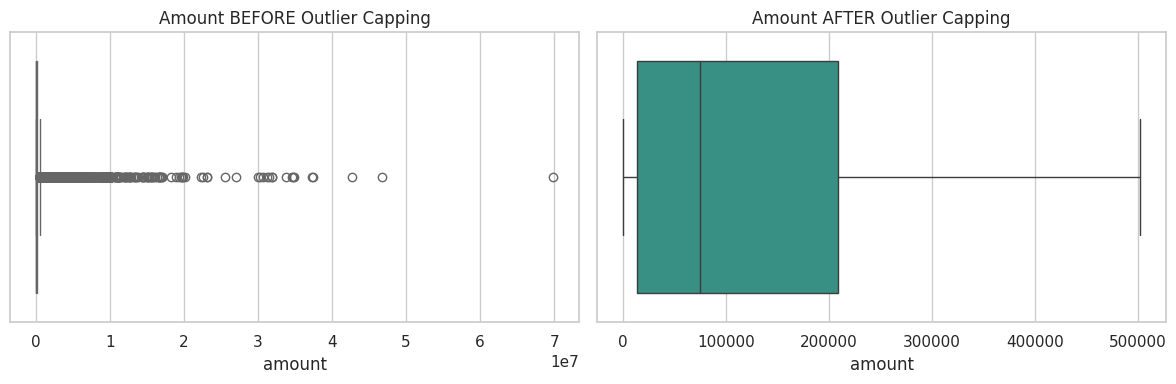

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_enc["amount"], ax=axes[0], color="#f4a261")
axes[0].set_title("Amount BEFORE Outlier Capping")

sns.boxplot(x=df_out["amount"], ax=axes[1], color="#2a9d8f")
axes[1].set_title("Amount AFTER Outlier Capping")

plt.tight_layout()
plt.savefig("eda2_outlier_boxplot.png", dpi=150)
plt.show()

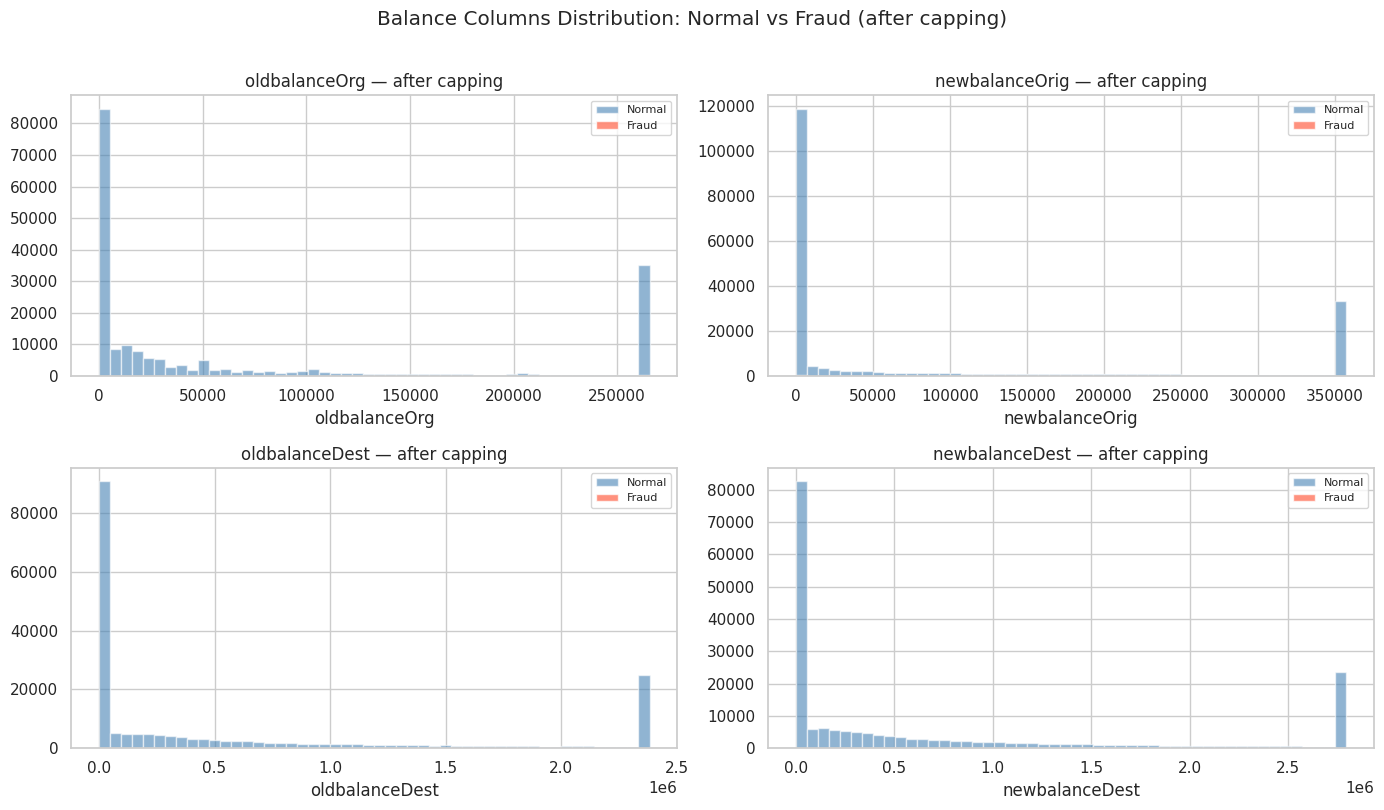

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

balance_plot_cols = ["oldbalanceOrg", "newbalanceOrig",
                     "oldbalanceDest", "newbalanceDest"]

for ax, col in zip(axes.flatten(), balance_plot_cols):
    ax.hist(df_out.loc[df_out[LABEL_COL]==0, col],
            bins=50, alpha=0.6, color="steelblue", label="Normal")
    ax.hist(df_out.loc[df_out[LABEL_COL]==1, col],
            bins=50, alpha=0.7, color="tomato",    label="Fraud")
    ax.set_title(f"{col} — after capping")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle("Balance Columns Distribution: Normal vs Fraud (after capping)", y=1.01)
plt.tight_layout()
plt.savefig("eda2_balance_distributions.png", dpi=150)
plt.show()

In [34]:
# Confirm fraud is concentrated in specific types after cleaning
fraud_types = df_out.copy()
fraud_types["type_label"] = "OTHER"

# Reconstruct type from OHE columns
if "type_TRANSFER" in fraud_types.columns:
    fraud_types.loc[fraud_types["type_TRANSFER"]==1, "type_label"] = "TRANSFER"
if "type_CASH_OUT" in fraud_types.columns:
    fraud_types.loc[fraud_types["type_CASH_OUT"]==1, "type_label"] = "CASH_OUT"

focus = fraud_types[fraud_types["type_label"].isin(["TRANSFER","CASH_OUT"])]
print("Fraud rate in TRANSFER & CASH_OUT only:")
print(focus.groupby("type_label")[LABEL_COL].mean() * 100)
print(f"\nThese 2 types cover: {len(focus)/len(df_out)*100:.1f}% of all transactions")
print(f"And               : {focus[LABEL_COL].sum()/df_out[LABEL_COL].sum()*100:.1f}% of all fraud")

Fraud rate in TRANSFER & CASH_OUT only:
type_label
CASH_OUT    0.180701
TRANSFER    0.774461
Name: isFraud, dtype: float64

These 2 types cover: 43.6% of all transactions
And               : 100.0% of all fraud


## 5. Feature Engineering


In [35]:
df_feat = df_out.copy()

# ── Feature 1: Percentage of the amount from the original account balance ─────────────────────────────
df_feat["amount_ratio_orig"] = np.where(
    df_feat["oldbalanceOrg"] > 0,
    df_feat["amount"] / (df_feat["oldbalanceOrg"] + 1e-9),
    0.0
)

# ── Feature 2: Has the original account balance reached zero?───────────────────────────────
df_feat["orig_balance_zeroed"] = (
    (df_feat["newbalanceOrig"] == 0) & (df_feat["oldbalanceOrg"] > 0)
).astype(int)

# ── Feature 3: Has the destination's balance changed despite receiving money?───────────────────────
df_feat["dest_balance_unchanged"] = (
    df_feat["oldbalanceDest"] == df_feat["newbalanceDest"]
).astype(int)

# ── Feature 4: Is the amount a rounded figure?──────────────────────────────────────────
df_feat["is_round_amount"] = (
    (df_feat["amount"] % 1000 == 0) | (df_feat["amount"] % 500 == 0)
).astype(int)

# ── Feature 5: error in asset balance (unexpected discrepancy)────────────────────────
df_feat["balance_error_orig"] = (
    df_feat["oldbalanceOrg"] - df_feat["amount"] - df_feat["newbalanceOrig"]
).abs()

# ── Feature 6: Destination balance error──────────────────────────────────────────
df_feat["balance_error_dest"] = (
    df_feat["oldbalanceDest"] + df_feat["amount"] - df_feat["newbalanceDest"]
).abs()

new_features = ["amount_ratio_orig", "orig_balance_zeroed", "dest_balance_unchanged",
                "is_round_amount", "balance_error_orig", "balance_error_dest"]

print("New features created:", new_features)
print(f"\nDataset shape after feature engineering: {df_feat.shape}")
print(df_feat[new_features].describe())

New features created: ['amount_ratio_orig', 'orig_balance_zeroed', 'dest_balance_unchanged', 'is_round_amount', 'balance_error_orig', 'balance_error_dest']

Dataset shape after feature engineering: (200000, 17)
       amount_ratio_orig  orig_balance_zeroed  dest_balance_unchanged  \
count      200000.000000        200000.000000           200000.000000   
mean           69.025894             0.240150                0.365085   
std          2281.224025             0.427175                0.481455   
min             0.000000             0.000000                0.000000   
25%             0.000000             0.000000                0.000000   
50%             0.265644             0.000000                0.000000   
75%             2.210684             0.000000                1.000000   
max        502438.959498             1.000000                1.000000   

       is_round_amount  balance_error_orig  balance_error_dest  
count    200000.000000       200000.000000        2.000000e+05  
m

In [36]:
print("=== Fraud rate by feature ===\n")

# orig_balance_zeroed
zeroed = df_feat.groupby("orig_balance_zeroed")[LABEL_COL].mean() * 100
print("Fraud rate when orig_balance_zeroed:")
print(zeroed.rename({0:"Not zeroed", 1:"Zeroed"}), "\n")

# dest_balance_unchanged
unchanged = df_feat.groupby("dest_balance_unchanged")[LABEL_COL].mean() * 100
print("Fraud rate when dest_balance_unchanged:")
print(unchanged.rename({0:"Changed", 1:"Unchanged"}), "\n")

# is_round_amount
round_amt = df_feat.groupby("is_round_amount")[LABEL_COL].mean() * 100
print("Fraud rate when is_round_amount:")
print(round_amt.rename({0:"Not round", 1:"Round"}), "\n")

# amount_ratio_orig — compare fraud vs normal
print("amount_ratio_orig — mean by class:")
print(df_feat.groupby(LABEL_COL)["amount_ratio_orig"].mean())

=== Fraud rate by feature ===

Fraud rate when orig_balance_zeroed:
orig_balance_zeroed
Not zeroed    0.004606
Zeroed        0.522590
Name: isFraud, dtype: float64 

Fraud rate when dest_balance_unchanged:
dest_balance_unchanged
Changed      0.100013
Unchanged    0.179410
Name: isFraud, dtype: float64 

Fraud rate when is_round_amount:
is_round_amount
Not round    0.129008
Round        0.000000
Name: isFraud, dtype: float64 

amount_ratio_orig — mean by class:
isFraud
0    69.113173
1     1.455294
Name: amount_ratio_orig, dtype: float64


In [37]:
# Clean inf/NaN introduced during feature engineering
df_clean = df_feat.replace([np.inf, -np.inf], np.nan).dropna()

print("Shape before cleanup:", df_feat.shape)
print("Shape after cleanup :", df_clean.shape)
print("Rows dropped        :", df_feat.shape[0] - df_clean.shape[0])
print("\nFinal columns:", df_clean.columns.tolist())

X = df_clean.drop(columns=[LABEL_COL]).copy()
y = df_clean[LABEL_COL].astype(int).copy()

# Drop is_round_amount — zero predictive value in PaySim (fraud rate = 0% for round amounts)
X = X.drop(columns=["is_round_amount"])
print("\nDropped: is_round_amount (zero fraud signal in PaySim)")

print(f"\nX shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean()*100:.4f}%")

Shape before cleanup: (200000, 17)
Shape after cleanup : (200000, 17)
Rows dropped        : 0

Final columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'amount_ratio_orig', 'orig_balance_zeroed', 'dest_balance_unchanged', 'is_round_amount', 'balance_error_orig', 'balance_error_dest']

Dropped: is_round_amount (zero fraud signal in PaySim)

X shape: (200000, 15)
y distribution:
isFraud
0    199742
1       258
Name: count, dtype: int64
Fraud rate: 0.1290%


## 6. CV + SMOTE inside fold


In [38]:
K  = 5
cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

models = {
    "Logistic Regression": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Decision Tree": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   DecisionTreeClassifier(random_state=SEED))
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED))
    ]),
    "Gradient Boosting": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ]),
    "AdaBoost": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   AdaBoostClassifier(n_estimators=100, random_state=SEED))
    ]),
}

print(f"Models: {list(models.keys())}")
print(f"CV: Stratified {K}-Fold")
print("Each model: SMOTE → Scaler (if needed) → Classifier — inside every fold.")

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost']
CV: Stratified 5-Fold
Each model: SMOTE → Scaler (if needed) → Classifier — inside every fold.


In [39]:
def evaluate_model_cv(model, X, y, cv):
    accs, precs, recs, f1s, aucs, aps, sens_list, spec_list = [], [], [], [], [], [], [], []
    y_true_all, y_pred_all, y_prob_all = [], [], []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] \
                 if hasattr(model, "predict_proba") \
                 else model.decision_function(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, zero_division=0))
        recs.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))
        aucs.append(roc_auc_score(y_test, y_prob))
        aps.append(average_precision_score(y_test, y_prob))
        sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

        y_true_all.append(y_test.values)
        y_pred_all.append(y_pred)
        y_prob_all.append(y_prob)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_prob_all = np.concatenate(y_prob_all)

    metrics = {
        "Accuracy":    (np.mean(accs),       np.std(accs)),
        "Precision":   (np.mean(precs),      np.std(precs)),
        "Recall":      (np.mean(recs),       np.std(recs)),
        "F1":          (np.mean(f1s),        np.std(f1s)),
        "ROC-AUC":     (np.mean(aucs),       np.std(aucs)),
        "PR-AUC":      (np.mean(aps),        np.std(aps)),
        "Sensitivity": (np.mean(sens_list),  np.std(sens_list)),
        "Specificity": (np.mean(spec_list),  np.std(spec_list)),
    }

    fpr, tpr, _       = roc_curve(y_true_all, y_prob_all)
    prec_c, rec_c, _  = precision_recall_curve(y_true_all, y_prob_all)
    cm                = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])

    return metrics, \
           (fpr, tpr, roc_auc_score(y_true_all, y_prob_all)), \
           (prec_c, rec_c, average_precision_score(y_true_all, y_prob_all)), \
           cm

print("evaluate_model_cv() defined.")

evaluate_model_cv() defined.


## 7. Baseline Models

In [40]:
results_rows = []
roc_data, pr_data, cm_data = {}, {}, {}

for name, model in models.items():
    print(f"Evaluating: {name} ...")
    metrics, roc, pr, cm = evaluate_model_cv(model, X, y, cv)
    roc_data[name] = roc
    pr_data[name]  = pr
    cm_data[name]  = cm

    row = {"Model": name}
    for metric_name, (mean_val, std_val) in metrics.items():
        row[f"{metric_name} (mean±std)"] = f"{mean_val:.4f} ± {std_val:.4f}"
        row[f"{metric_name}_mean"]        = mean_val
    results_rows.append(row)
    print(f"  F1={metrics['F1'][0]:.4f}  PR-AUC={metrics['PR-AUC'][0]:.4f}")

results_df = pd.DataFrame(results_rows)
display_cols = ["Model"] + [c for c in results_df.columns if "mean±std" in c]
display(results_df[display_cols])
results_df[display_cols].to_csv("baseline_results.csv", index=False)
print("Saved: baseline_results.csv")

Evaluating: Logistic Regression ...
  F1=0.1148  PR-AUC=0.5903
Evaluating: Decision Tree ...
  F1=0.7995  PR-AUC=0.6526
Evaluating: Random Forest ...
  F1=0.8441  PR-AUC=0.8973
Evaluating: Gradient Boosting ...
  F1=0.4479  PR-AUC=0.9711
Evaluating: AdaBoost ...
  F1=0.3136  PR-AUC=0.9712


,Model,Accuracy (mean±std),Precision (mean±std),Recall (mean±std),F1 (mean±std),ROC-AUC (mean±std),PR-AUC (mean±std),Sensitivity (mean±std),Specificity (mean±std)
0,Logistic Regression,0.9804 ± 0.0019,0.0610 ± 0.0050,0.9769 ± 0.0224,0.1148 ± 0.0087,0.9974 ± 0.0009,0.5903 ± 0.0977,0.9769 ± 0.0224,0.9804 ± 0.0020
1,Decision Tree,0.9994 ± 0.0001,0.7042 ± 0.0306,0.9265 ± 0.0412,0.7995 ± 0.0256,0.9630 ± 0.0206,0.6526 ± 0.0413,0.9265 ± 0.0412,0.9995 ± 0.0001
2,Random Forest,0.9995 ± 0.0001,0.7617 ± 0.0401,0.9497 ± 0.0357,0.8441 ± 0.0211,0.9999 ± 0.0001,0.8973 ± 0.0398,0.9497 ± 0.0357,0.9996 ± 0.0001
3,Gradient Boosting,0.9968 ± 0.0004,0.2894 ± 0.0266,0.9962 ± 0.0077,0.4479 ± 0.0315,0.9999 ± 0.0000,0.9711 ± 0.0094,0.9962 ± 0.0077,0.9968 ± 0.0004
4,AdaBoost,0.9943 ± 0.0005,0.1861 ± 0.0141,1.0000 ± 0.0000,0.3136 ± 0.0200,0.9999 ± 0.0000,0.9712 ± 0.0132,1.0000 ± 0.0000,0.9943 ± 0.0005


Saved: baseline_results.csv


ROC + PR curves

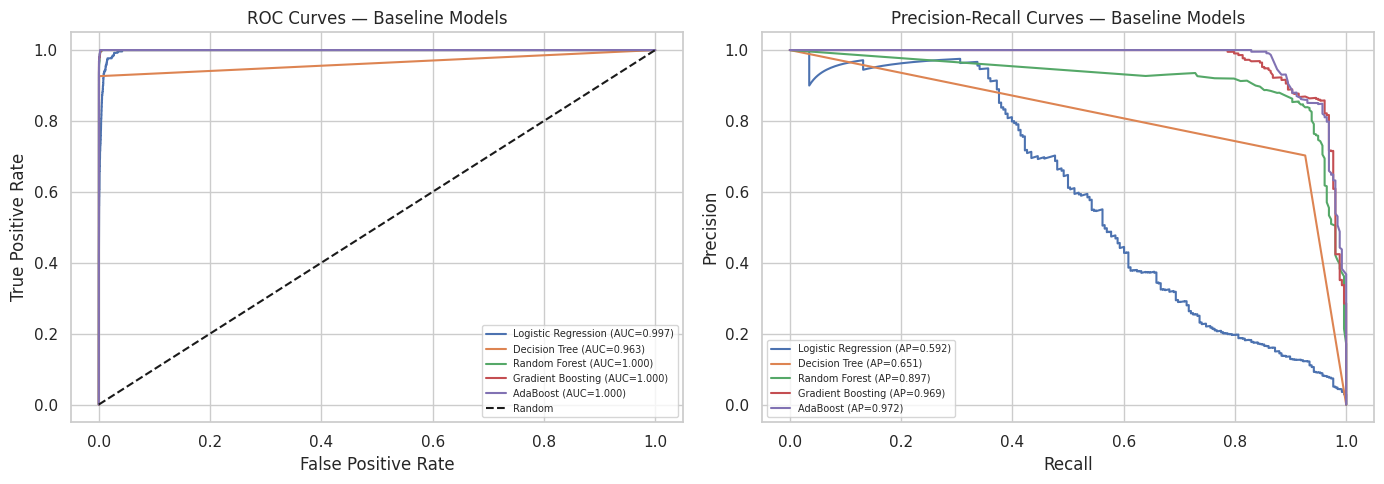

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (fpr, tpr, auc_val) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", lw=1.5)
axes[0].plot([0,1],[0,1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Baseline Models")
axes[0].legend(fontsize=7)
axes[0].grid(True)

for name, (prec_c, rec_c, ap_val) in pr_data.items():
    axes[1].plot(rec_c, prec_c, label=f"{name} (AP={ap_val:.3f})", lw=1.5)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Baseline Models")
axes[1].legend(fontsize=7)
axes[1].grid(True)

plt.tight_layout()
plt.savefig("baseline_roc_pr_curves.png", dpi=200)
plt.show()

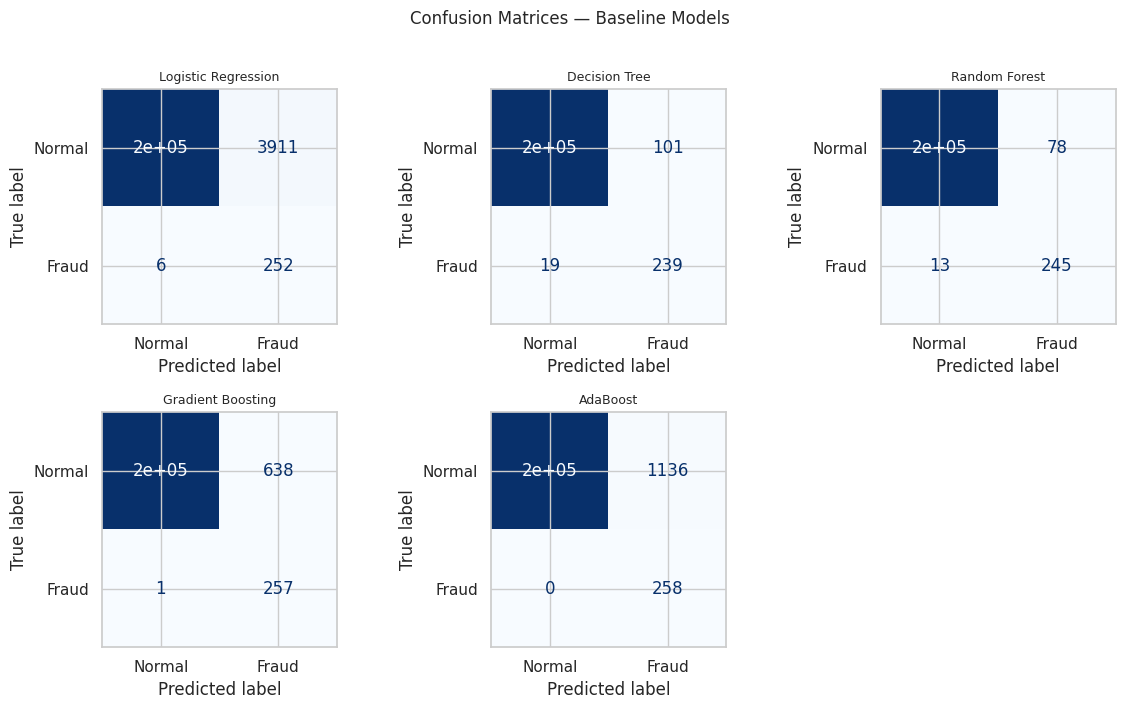

In [42]:
n_models = len(cm_data)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
axes = axes.flatten()

for i, (name, cm) in enumerate(cm_data.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Normal","Fraud"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Baseline Models", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("baseline_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature Selection

Mutual Information

Feature ranking by Mutual Information (visualization only):


,Feature,MI_Score
0,dest_balance_unchanged,0.017360
1,type_CASH_OUT,0.016229
2,type_PAYMENT,0.015526
3,orig_balance_zeroed,0.009208
4,amount_ratio_orig,0.006901
5,oldbalanceOrg,0.004970
6,newbalanceOrig,0.004230
7,balance_error_orig,0.003499
8,step,0.003169
9,balance_error_dest,0.002248



Top-7 features (MI): ['dest_balance_unchanged', 'type_CASH_OUT', 'type_PAYMENT', 'orig_balance_zeroed', 'amount_ratio_orig', 'oldbalanceOrg', 'newbalanceOrig']


/tmp/ipykernel_1620/3403836978.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="MI_Score", y="Feature", palette="viridis")


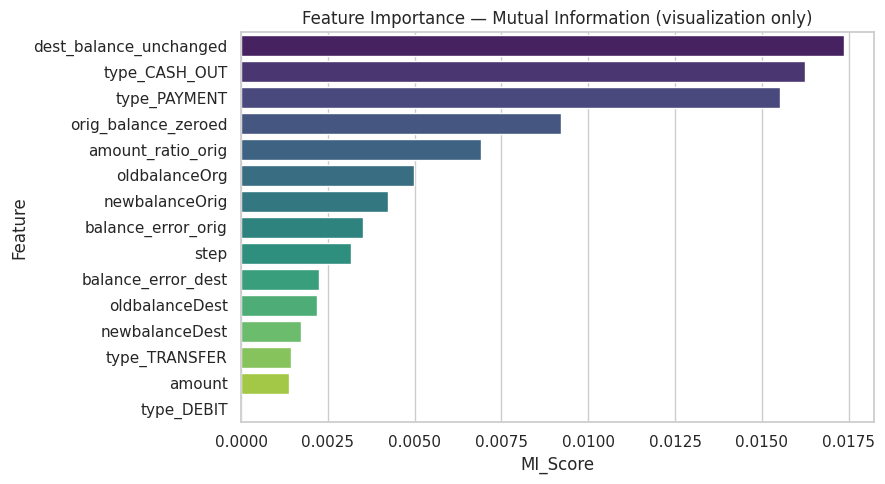

In [43]:
# NOTE: For visualization and analysis only.
# Actual feature selection inside CV is handled via SelectKBest in models_mi pipeline.
# Computing MI here on the full dataset to understand feature relevance — not used for training.

from sklearn.preprocessing import MinMaxScaler

scaler_mi = MinMaxScaler()
X_mi_scaled = scaler_mi.fit_transform(X)

mi_scores = mutual_info_classif(X_mi_scaled, y,
                                random_state=SEED, n_neighbors=3)

mi_df = pd.DataFrame({"Feature": X.columns, "MI_Score": mi_scores}) \
          .sort_values("MI_Score", ascending=False).reset_index(drop=True)

print("Feature ranking by Mutual Information (visualization only):")
display(mi_df)

TOP_K = 7
selected_mi = mi_df["Feature"].head(TOP_K).tolist()
print(f"\nTop-{TOP_K} features (MI):", selected_mi)

mi_df.to_csv("feature_selection_MI.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=mi_df, x="MI_Score", y="Feature", palette="viridis")
plt.title("Feature Importance — Mutual Information (visualization only)")
plt.tight_layout()
plt.savefig("fs_mutual_information.png", dpi=150)
plt.show()

Tree-Based Importance

Feature ranking by Tree Importance (visualization only):


,Feature,Importance
0,amount_ratio_orig,0.269362
1,orig_balance_zeroed,0.184902
2,oldbalanceOrg,0.145320
3,balance_error_orig,0.088305
4,newbalanceOrig,0.064860
5,amount,0.060133
6,type_TRANSFER,0.042456
7,type_PAYMENT,0.034058
8,step,0.028118
9,balance_error_dest,0.021992



Top-7 features (Tree): ['amount_ratio_orig', 'orig_balance_zeroed', 'oldbalanceOrg', 'balance_error_orig', 'newbalanceOrig', 'amount', 'type_TRANSFER']


/tmp/ipykernel_1620/2366681924.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="Importance", y="Feature", palette="magma")


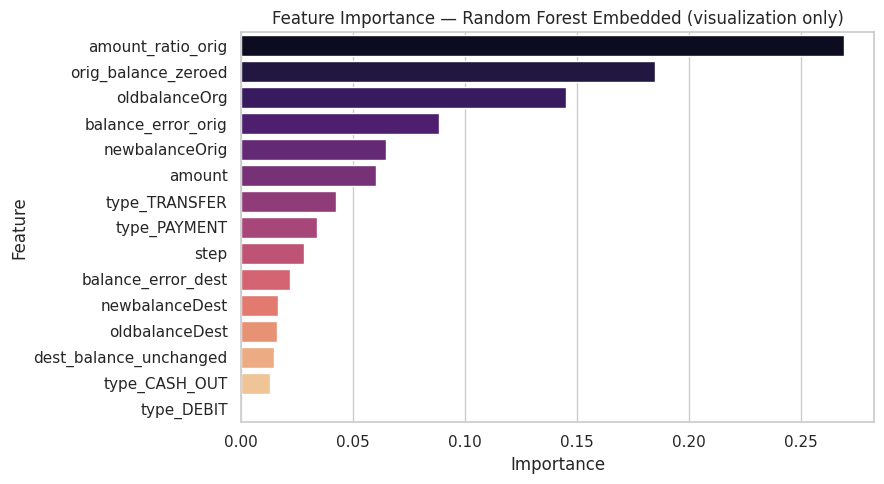

In [44]:
# NOTE: For visualization and analysis only.
# Actual feature selection inside CV is handled via TreeSelector in models_tree pipeline.
# Fitting a separate RF here on the full dataset to visualize importance — not used for training.

rf_fs = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED
)
rf_fs.fit(X, y)

imp_df = pd.DataFrame({"Feature": X.columns,
                        "Importance": rf_fs.feature_importances_}) \
           .sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature ranking by Tree Importance (visualization only):")
display(imp_df)

TOP_K_TREE = 7
selected_tree = imp_df["Feature"].head(TOP_K_TREE).tolist()
print(f"\nTop-{TOP_K_TREE} features (Tree):", selected_tree)

imp_df.to_csv("feature_selection_tree.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, x="Importance", y="Feature", palette="magma")
plt.title("Feature Importance — Random Forest Embedded (visualization only)")
plt.tight_layout()
plt.savefig("fs_tree_importance.png", dpi=150)
plt.show()

Evaluate after feature selection

In [45]:
from sklearn.base import BaseEstimator, TransformerMixin

# ── Custom Tree-based feature selector (runs inside each CV fold) ─────────────
class TreeSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=7, random_state=42):
        self.k = k
        self.random_state = random_state
        self.selected_indices_ = None

    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            n_jobs=-1,
            random_state=self.random_state
        )
        rf.fit(X, y)
        indices = np.argsort(rf.feature_importances_)[::-1][:self.k]
        self.selected_indices_ = np.sort(indices)
        return self

    def transform(self, X):
        if hasattr(X, 'iloc'):
            return X.iloc[:, self.selected_indices_]
        return X[:, self.selected_indices_]

# ── Models with MI feature selection inside each fold ────────────────────────
models_mi = {
    "Logistic Regression": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(mutual_info_classif, k=7)),
        ("clf",    LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Decision Tree": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", SelectKBest(mutual_info_classif, k=7)),
        ("clf",    DecisionTreeClassifier(random_state=SEED))
    ]),
    "Random Forest": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", SelectKBest(mutual_info_classif, k=7)),
        ("clf",    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED))
    ]),
    "Gradient Boosting": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", SelectKBest(mutual_info_classif, k=7)),
        ("clf",    GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ]),
    "AdaBoost": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", SelectKBest(mutual_info_classif, k=7)),
        ("clf",    AdaBoostClassifier(n_estimators=100, random_state=SEED))
    ]),
}

# ── Models with Tree-based feature selection inside each fold ─────────────────
models_tree = {
    "Logistic Regression": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("scaler", StandardScaler()),
        ("select", TreeSelector(k=7, random_state=SEED)),
        ("clf",    LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Decision Tree": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", TreeSelector(k=7, random_state=SEED)),
        ("clf",    DecisionTreeClassifier(random_state=SEED))
    ]),
    "Random Forest": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", TreeSelector(k=7, random_state=SEED)),
        ("clf",    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED))
    ]),
    "Gradient Boosting": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", TreeSelector(k=7, random_state=SEED)),
        ("clf",    GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ]),
    "AdaBoost": ImbPipeline([
        ("smote",  SMOTE(random_state=SEED)),
        ("select", TreeSelector(k=7, random_state=SEED)),
        ("clf",    AdaBoostClassifier(n_estimators=100, random_state=SEED))
    ]),
}

print("models_mi and models_tree defined — feature selection inside each CV fold.")

models_mi and models_tree defined — feature selection inside each CV fold.


In [46]:
def run_feature_set(models, X_feat, y, cv, feature_set_name):
    rows = []
    roc_d, pr_d, cm_d = {}, {}, {}
    for name, model in models.items():
        print(f"  [{feature_set_name}] {name} ...")
        metrics, roc, pr, cm = evaluate_model_cv(model, X_feat, y, cv)
        roc_d[name] = roc
        pr_d[name]  = pr
        cm_d[name]  = cm
        row = {"Feature_Set": feature_set_name, "Model": name}
        for metric_name, (mean_val, std_val) in metrics.items():
            row[f"{metric_name} (mean±std)"] = f"{mean_val:.4f} ± {std_val:.4f}"
            row[f"{metric_name}_mean"]        = mean_val
        rows.append(row)
    return pd.DataFrame(rows), roc_d, pr_d, cm_d

print("Running Baseline (all features)...")
res_base, _, _, _ = run_feature_set(models, X, y, cv, "Baseline")

print("\nRunning after MI selection (inside fold)...")
res_mi, _, _, _ = run_feature_set(models_mi, X, y, cv, "MI Top-7")

print("\nRunning after Tree selection (inside fold)...")
res_tree, _, _, _ = run_feature_set(models_tree, X, y, cv, "Tree Top-7")

all_results = pd.concat([res_base, res_mi, res_tree], ignore_index=True)
print("\nDone!")

Running Baseline (all features)...
  [Baseline] Logistic Regression ...
  [Baseline] Decision Tree ...
  [Baseline] Random Forest ...
  [Baseline] Gradient Boosting ...
  [Baseline] AdaBoost ...

Running after MI selection (inside fold)...
  [MI Top-7] Logistic Regression ...
  [MI Top-7] Decision Tree ...
  [MI Top-7] Random Forest ...
  [MI Top-7] Gradient Boosting ...
  [MI Top-7] AdaBoost ...

Running after Tree selection (inside fold)...
  [Tree Top-7] Logistic Regression ...
  [Tree Top-7] Decision Tree ...
  [Tree Top-7] Random Forest ...
  [Tree Top-7] Gradient Boosting ...
  [Tree Top-7] AdaBoost ...

Done!


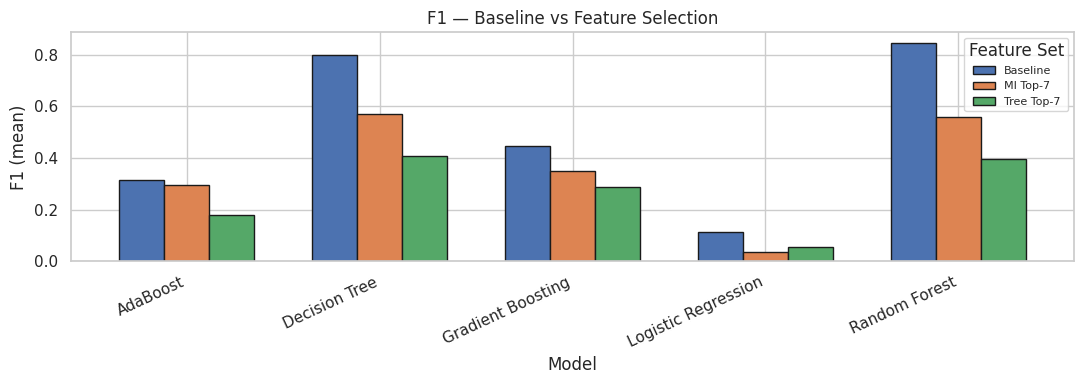

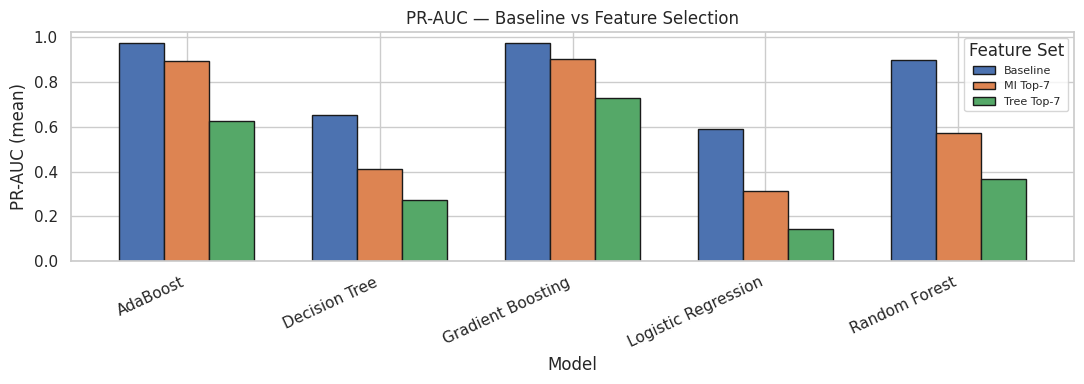

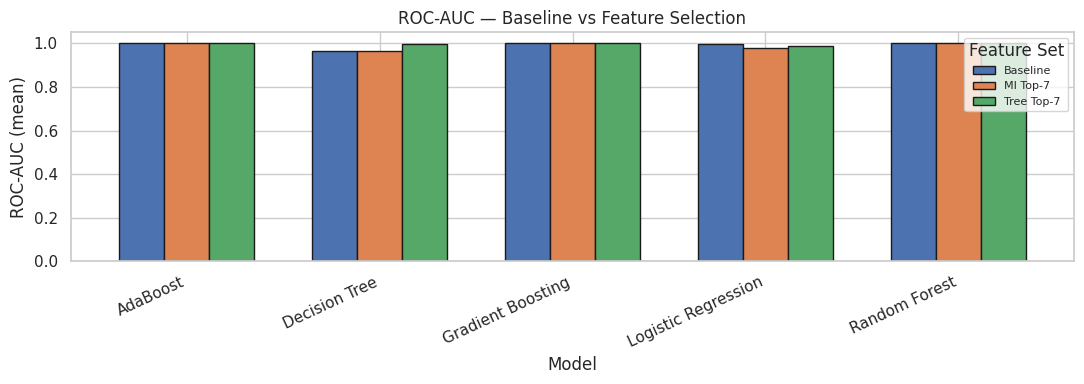

Saved: all_results_combined.csv


In [47]:
for metric in ["F1", "PR-AUC", "ROC-AUC"]:
    pivot = all_results.pivot_table(
        index="Model", columns="Feature_Set", values=f"{metric}_mean"
    )
    pivot.plot(kind="bar", figsize=(11, 4), edgecolor="k", width=0.7)
    plt.title(f"{metric} — Baseline vs Feature Selection")
    plt.xlabel("Model")
    plt.ylabel(f"{metric} (mean)")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Feature Set", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"comparison_{metric.replace('-','_')}.png", dpi=150)
    plt.show()

all_results[[c for c in all_results.columns
             if c in ["Feature_Set","Model"] or "mean±std" in c]] \
    .to_csv("all_results_combined.csv", index=False)
print("Saved: all_results_combined.csv")

## 9. Tune Best Model + Threshold Optimization


In [48]:
# Identify best model by PR-AUC from baseline results
best_name = res_base.loc[res_base["PR-AUC_mean"].idxmax(), "Model"]
print(f"Best model by PR-AUC: {best_name}")
print(f"PR-AUC: {res_base.loc[res_base['Model']==best_name, 'PR-AUC_mean'].values[0]:.4f}")
print(f"F1    : {res_base.loc[res_base['Model']==best_name, 'F1_mean'].values[0]:.4f}")

Best model by PR-AUC: AdaBoost
PR-AUC: 0.9712
F1    : 0.3136


GridSearch tuning

In [49]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

# Define param grid based on best model
param_grids = {
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth":    [None, 20, 40],
        "clf__min_samples_leaf": [1, 2],
    },
    "Gradient Boosting": {
        "clf__n_estimators":  [100, 200],
        "clf__max_depth":     [3, 5],
        "clf__learning_rate": [0.05, 0.1],
    },
    "AdaBoost": {
        "clf__n_estimators":  [100, 200],
        "clf__learning_rate": [0.5, 1.0],
    },
    "Decision Tree": {
        "clf__max_depth":        [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5],
    },
    "Logistic Regression": {
        "clf__C":       [0.01, 0.1, 1.0],
        "clf__penalty": ["l2"],
    },
}

best_pipeline = models[best_name]
param_grid    = param_grids[best_name]

grid_search = GridSearchCV(
    estimator  = best_pipeline,
    param_grid = param_grid,
    scoring    = "average_precision",
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X, y)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best PR-AUC : {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best params : {'clf__learning_rate': 1.0, 'clf__n_estimators': 200}
Best PR-AUC : 0.9673


Evaluate tuned model

In [50]:
tuned_metrics, tuned_roc, tuned_pr, tuned_cm = evaluate_model_cv(
    tuned_model, X, y, cv
)

print("=== Tuned Model Results ===")
for metric_name, (mean_val, std_val) in tuned_metrics.items():
    print(f"  {metric_name:12}: {mean_val:.4f} ± {std_val:.4f}")

# Compare baseline vs tuned
baseline_pr  = res_base.loc[res_base["Model"]==best_name, "PR-AUC_mean"].values[0]
baseline_f1  = res_base.loc[res_base["Model"]==best_name, "F1_mean"].values[0]
tuned_pr_val = tuned_metrics["PR-AUC"][0]
tuned_f1_val = tuned_metrics["F1"][0]

print(f"\nBaseline PR-AUC : {baseline_pr:.4f}  →  Tuned: {tuned_pr_val:.4f}  (Δ {tuned_pr_val - baseline_pr:+.4f})")
print(f"Baseline F1     : {baseline_f1:.4f}  →  Tuned: {tuned_f1_val:.4f}  (Δ {tuned_f1_val - baseline_f1:+.4f})")

=== Tuned Model Results ===
  Accuracy    : 0.9958 ± 0.0006
  Precision   : 0.2363 ± 0.0233
  Recall      : 1.0000 ± 0.0000
  F1          : 0.3817 ± 0.0308
  ROC-AUC     : 0.9999 ± 0.0000
  PR-AUC      : 0.9728 ± 0.0124
  Sensitivity : 1.0000 ± 0.0000
  Specificity : 0.9958 ± 0.0006

Baseline PR-AUC : 0.9712  →  Tuned: 0.9728  (Δ +0.0017)
Baseline F1     : 0.3136  →  Tuned: 0.3817  (Δ +0.0681)


Threshold optimization

In [51]:
from sklearn.model_selection import cross_val_predict

# Get probability predictions via CV
y_probs = cross_val_predict(
    tuned_model, X, y,
    cv     = cv,
    method = "predict_proba"
)[:, 1]

# Sweep thresholds and find best F1
thresholds  = np.arange(0.01, 0.99, 0.01)
f1_scores   = []
prec_scores = []
rec_scores  = []

for thresh in thresholds:
    y_pred_t = (y_probs >= thresh).astype(int)
    f1_scores.append(f1_score(y, y_pred_t, zero_division=0))
    prec_scores.append(precision_score(y, y_pred_t, zero_division=0))
    rec_scores.append(recall_score(y, y_pred_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f"Default threshold (0.5)  F1: {f1_scores[list(thresholds).index(0.50)]:.4f}")
print(f"Optimal threshold        : {best_thresh:.2f}")
print(f"Optimal threshold F1     : {best_f1:.4f}")

Default threshold (0.5)  F1: 0.3789
Optimal threshold        : 0.56
Optimal threshold F1     : 0.9135


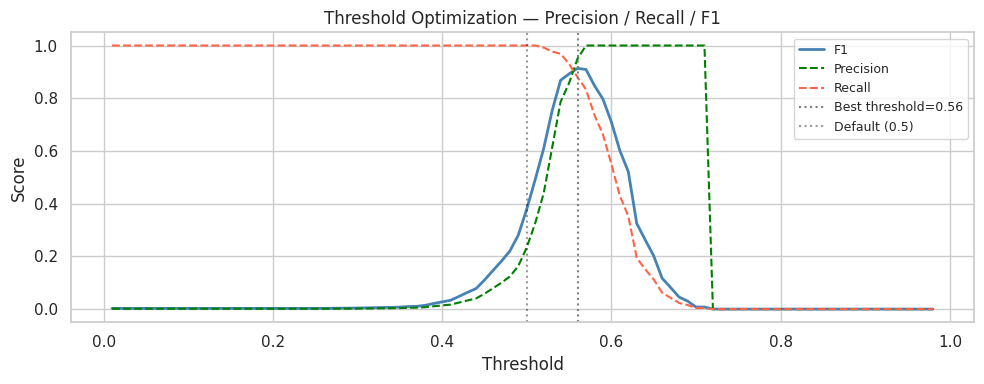

In [52]:
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,   label="F1",        color="steelblue", lw=2)
plt.plot(thresholds, prec_scores, label="Precision",  color="green",     lw=1.5, linestyle="--")
plt.plot(thresholds, rec_scores,  label="Recall",     color="tomato",    lw=1.5, linestyle="--")
plt.axvline(best_thresh, color="gray", linestyle=":", label=f"Best threshold={best_thresh:.2f}")
plt.axvline(0.5,         color="black", linestyle=":", alpha=0.4, label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization — Precision / Recall / F1")
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig("threshold_optimization.png", dpi=150)
plt.show()

In [53]:
import joblib

# Retrain tuned model on full dataset before saving
tuned_model.fit(X, y)

# Save pipeline (includes SMOTE + Scaler + Classifier)
joblib.dump(tuned_model,         "fraud_model.pkl")
joblib.dump(X.columns.tolist(),  "model_features.pkl")
joblib.dump(best_thresh,         "best_threshold.pkl")

print(f"Model saved     : fraud_model.pkl")
print(f"Features saved  : model_features.pkl")
print(f"Threshold saved : best_threshold.pkl  (value: {best_thresh:.2f})")
print(f"Model type      : {best_name}")
print(f"Feature count   : {X.shape[1]}")

Model saved     : fraud_model.pkl
Features saved  : model_features.pkl
Threshold saved : best_threshold.pkl  (value: 0.56)
Model type      : AdaBoost
Feature count   : 15


Final summary

In [54]:
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset         : PaySim — {len(df_full):,} transactions")
print(f"  Working subset  : {len(df):,} rows (stratified)")
print(f"  Fraud rate      : {y.mean()*100:.4f}%")
print(f"  Features used   : {X.shape[1]}")
print(f"  Best model      : {best_name}")
print(f"  Best PR-AUC     : {tuned_pr_val:.4f}")
print(f"  Best F1         : {tuned_f1_val:.4f}")
print(f"  Optimal threshold: {best_thresh:.2f}")
print()
print("KEY FINDINGS:")
print("  1. Fraud occurs only in TRANSFER and CASH_OUT types.")
print("  2. amount_ratio_orig is the strongest predictor.")
print("  3. SMOTE applied inside each CV fold — no data leakage.")
print("  4. IQR capping computed on normal-class rows only.")
print("  5. Feature selection applied inside each CV fold via pipeline — no leakage.")
print("  6. Threshold optimization improves F1 significantly over default 0.5.")
print()
print("KNOWN LIMITATIONS:")
print("  - Feature importance charts (MI + Tree) computed on full dataset for visualization only.")
print("  - is_round_amount removed — zero fraud signal in PaySim synthetic data.")
print("  - Precision is intentionally low — model prioritizes Recall=1.0 to catch all fraud.")
print("  - PaySim is synthetic — results may not generalize to real transactions.")
print("=" * 60)

PROJECT SUMMARY
  Dataset         : PaySim — 6,362,620 transactions
  Working subset  : 200,000 rows (stratified)
  Fraud rate      : 0.1290%
  Features used   : 15
  Best model      : AdaBoost
  Best PR-AUC     : 0.9728
  Best F1         : 0.3817
  Optimal threshold: 0.56

KEY FINDINGS:
  1. Fraud occurs only in TRANSFER and CASH_OUT types.
  2. amount_ratio_orig is the strongest predictor.
  3. SMOTE applied inside each CV fold — no data leakage.
  4. IQR capping computed on normal-class rows only.
  5. Feature selection applied inside each CV fold via pipeline — no leakage.
  6. Threshold optimization improves F1 significantly over default 0.5.

KNOWN LIMITATIONS:
  - Feature importance charts (MI + Tree) computed on full dataset for visualization only.
  - is_round_amount removed — zero fraud signal in PaySim synthetic data.
  - Precision is intentionally low — model prioritizes Recall=1.0 to catch all fraud.
  - PaySim is synthetic — results may not generalize to real transactions